Saving Expanded_Recipe_File.csv to Expanded_Recipe_File (10).csv
✅ File uploaded and loaded successfully.

🔍 Top 3 Recipes for: bread, cheese

🍽️ 1. Classic Grilled Cheese
📝 Ingredients: bread, cheese, butter
🧑‍🍳 Instructions: Butter the bread. Add cheese and grill until golden.
🎥 YouTube Link: https://www.youtube.com/watch?v=grilledcheese000
📏 Similarity Score: 0.83
————————————————————————————————————————————————————————————
🍽️ 2. French Toast
📝 Ingredients: bread, egg, milk, cinnamon, sugar
🧑‍🍳 Instructions: Dip bread in egg-milk mix with cinnamon. Fry until golden and serve with syrup.
🎥 YouTube Link: https://www.youtube.com/watch?v=frenchtoast321
📏 Similarity Score: 0.29
————————————————————————————————————————————————————————————
🍽️ 3. Egg Salad Sandwich
📝 Ingredients: egg, mayonnaise, bread, lettuce, mustard
🧑‍🍳 Instructions: Mix chopped boiled eggs with mayo and mustard. Serve in bread with lettuce.
🎥 YouTube Link: https://www.youtube.com/watch?v=eggsalad987
📏 Similarity Score:

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


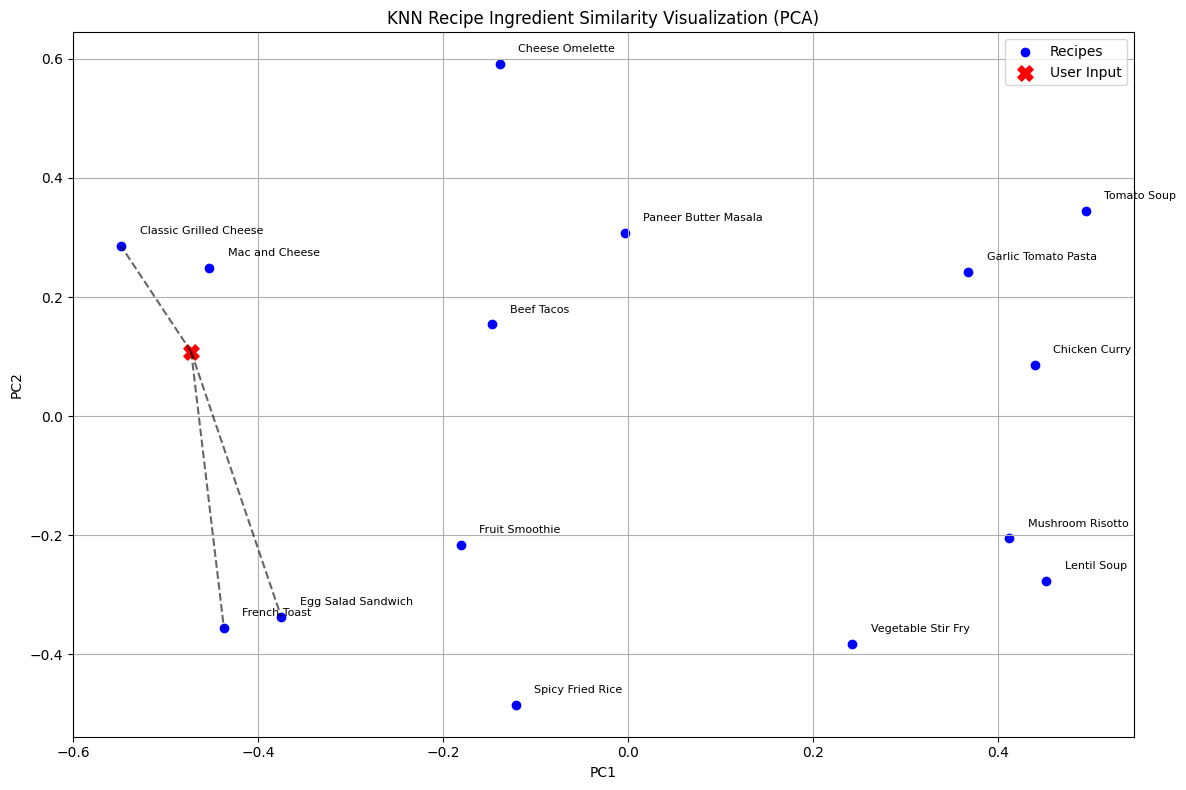

In [18]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from google.colab import files

# Step 1: Upload the CSV
uploaded = files.upload()
file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

# Step 2: Validate required columns
required_cols = {'title', 'ingredients', 'instructions'}
if not required_cols.issubset(df.columns):
    raise ValueError("❌ CSV must contain: title, ingredients, instructions columns.")
print("✅ File uploaded and loaded successfully.")

# Step 3: Clean ingredients
df.dropna(subset=['title', 'ingredients', 'instructions'], inplace=True)
df['ingredients_cleaned'] = df['ingredients'].str.lower().str.replace(r'[^a-zA-Z, ]', '', regex=True)
df['ingredients_cleaned'] = df['ingredients_cleaned'].str.replace(', ', ',')

# Step 4: TF-IDF vectorization
vectorizer = TfidfVectorizer(tokenizer=lambda x: x.split(','), lowercase=True)
ingredient_vectors = vectorizer.fit_transform(df['ingredients_cleaned'])

# Step 5: KNN model
knn_model = NearestNeighbors(metric='cosine', algorithm='brute')
knn_model.fit(ingredient_vectors)

# Step 6: Shared user input
user_input = "bread, cheese"  # 👈 This input will be used for both recommendation and plot
user_input_cleaned = user_input.lower().replace(', ', ',').replace(' ', '')
user_vector = vectorizer.transform([user_input_cleaned])
distances, indices = knn_model.kneighbors(user_vector, n_neighbors=3)

# Step 7: Recommend Recipes
print(f"\n🔍 Top 3 Recipes for: {user_input}\n")
for i, idx in enumerate(indices[0]):
    row = df.iloc[idx]
    print(f"🍽️ {i+1}. {row['title']}")
    print(f"📝 Ingredients: {row['ingredients']}")
    print(f"🧑‍🍳 Instructions: {row['instructions']}")
    if 'youtube_link' in row and pd.notna(row['youtube_link']):
        print(f"🎥 YouTube Link: {row['youtube_link']}")
    print(f"📏 Similarity Score: {1 - distances[0][i]:.2f}")
    print("—" * 60)

# Step 8: PCA for Visualization
pca = PCA(n_components=2)
components = pca.fit_transform(ingredient_vectors.toarray())
user_pca = pca.transform(user_vector.toarray())

# Step 9: Plotting
plt.figure(figsize=(12, 8))
plt.scatter(components[:, 0], components[:, 1], c='blue', label='Recipes')
plt.scatter(user_pca[:, 0], user_pca[:, 1], c='red', marker='X', s=120, label='User Input')

# Connect query to recommended recipes
for i in indices[0]:
    plt.plot([user_pca[0, 0], components[i, 0]], [user_pca[0, 1], components[i, 1]], 'k--', alpha=0.6)

# Label recipes
for i, title in enumerate(df['title']):
    plt.annotate(title, (components[i, 0] + 0.02, components[i, 1] + 0.02), fontsize=8)

plt.title("KNN Recipe Ingredient Similarity Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
